# Análise de Dados de Produtos - Marketplace Search System

Este notebook permite visualizar e analisar os dados de produtos do sistema de busca do marketplace. 
Utilizamos pandas, matplotlib e seaborn para criar visualizações interativas e insights sobre os produtos.

## Estrutura do Notebook:
1. **Importação de Bibliotecas** - Pandas, Matplotlib, Seaborn, Requests
2. **Carregamento de Dados** - Conectar ao Elasticsearch e carregar produtos
3. **Exploração e Limpeza** - Análise exploratória dos dados
4. **Visualizações Básicas** - Gráficos de distribuição e categorias
5. **Analytics Avançados** - Correlações e tendências
6. **Filtros Interativos** - Exploração dinâmica dos dados

## 1. Importação de Bibliotecas

Importamos todas as bibliotecas necessárias para análise de dados e visualização.

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
import json
import requests
from datetime import datetime, timedelta

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configurações do pandas e matplotlib
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configurações do Elasticsearch
ELASTICSEARCH_URL = "http://localhost:9200"
INDEX_NAME = "marketplace-products-dev"

print("✅ Bibliotecas importadas com sucesso!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")

✅ Bibliotecas importadas com sucesso!
📊 Pandas version: 2.3.3
📈 Matplotlib version: 3.10.7
🎨 Seaborn version: 0.13.2


## 2. Carregamento de Dados do Elasticsearch

Conectamos ao Elasticsearch e carregamos os dados de produtos para análise.

In [2]:
def load_products_from_elasticsearch(es_url=ELASTICSEARCH_URL, index=INDEX_NAME, size=1000):
    """
    Carrega produtos do Elasticsearch e converte para DataFrame do pandas
    """
    try:
        # Verificar se o Elasticsearch está rodando
        health_url = f"{es_url}/_cluster/health"
        health_response = requests.get(health_url)
        if health_response.status_code != 200:
            print("❌ Elasticsearch não está rodando. Verifique se o container está ativo.")
            return None
        
        print("✅ Elasticsearch está rodando!")
        
        # Buscar todos os produtos
        search_url = f"{es_url}/{index}/_search"
        query = {
            "query": {"match_all": {}},
            "size": size
        }
        
        response = requests.post(search_url, json=query, headers={'Content-Type': 'application/json'})
        
        if response.status_code != 200:
            print(f"❌ Erro ao buscar produtos: {response.text}")
            return None
        
        data = response.json()
        hits = data.get('hits', {}).get('hits', [])
        
        if not hits:
            print("⚠️  Nenhum produto encontrado no Elasticsearch.")
            return None
        
        # Converter para DataFrame
        products = []
        for hit in hits:
            source = hit['_source']
            product = {
                'id': source.get('id'),
                'name': source.get('name'),
                'description': source.get('description'),
                'price': source.get('price'),
                'category_id': source.get('category', {}).get('id'),
                'category_name': source.get('category', {}).get('name'),
                'brand_id': source.get('brand', {}).get('id'),
                'brand_name': source.get('brand', {}).get('name'),
                'seller_id': source.get('seller', {}).get('id'),
                'seller_name': source.get('seller', {}).get('name'),
                'seller_reputation': source.get('seller', {}).get('reputationScore'),
                'stock_quantity': source.get('stockQuantity'),
                'created_at': source.get('createdAt'),
                'updated_at': source.get('updatedAt'),
                'active': source.get('active', True)
            }
            products.append(product)
        
        df = pd.DataFrame(products)
        
        # Conversões de tipo
        if 'price' in df.columns:
            df['price'] = pd.to_numeric(df['price'], errors='coerce')
        if 'stock_quantity' in df.columns:
            df['stock_quantity'] = pd.to_numeric(df['stock_quantity'], errors='coerce')
        if 'seller_reputation' in df.columns:
            df['seller_reputation'] = pd.to_numeric(df['seller_reputation'], errors='coerce')
        
        # Conversões de data
        date_columns = ['created_at', 'updated_at']
        for col in date_columns:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')
        
        print(f"✅ Carregados {len(df)} produtos do Elasticsearch!")
        return df
        
    except Exception as e:
        print(f"❌ Erro ao conectar com Elasticsearch: {str(e)}")
        return None

# Carregar os dados
df_products = load_products_from_elasticsearch()

if df_products is not None:
    print(f"\n📊 Dataset carregado:")
    print(f"   • {len(df_products)} produtos")
    print(f"   • {len(df_products.columns)} colunas")
    print(f"   • Período: {df_products['created_at'].min()} até {df_products['created_at'].max()}")
else:
    print("⚠️  Criando dados de exemplo para demonstração...")
    # Dados de exemplo caso não consiga conectar no Elasticsearch
    np.random.seed(42)
    n_products = 100
    
    categories = ['Eletrônicos', 'Roupas', 'Casa e Jardim', 'Livros', 'Esportes', 'Beleza']
    brands = ['TechCorp', 'StyleBrand', 'HomePlus', 'BookWorld', 'SportMax', 'BeautyLux']
    sellers = ['Seller_A', 'Seller_B', 'Seller_C', 'Seller_D', 'Seller_E']
    
    df_products = pd.DataFrame({
        'id': range(1, n_products + 1),
        'name': [f'Produto {i}' for i in range(1, n_products + 1)],
        'description': [f'Descrição do produto {i}' for i in range(1, n_products + 1)],
        'price': np.random.uniform(10, 1000, n_products).round(2),
        'category_name': np.random.choice(categories, n_products),
        'brand_name': np.random.choice(brands, n_products),
        'seller_name': np.random.choice(sellers, n_products),
        'seller_reputation': np.random.uniform(1, 5, n_products).round(1),
        'stock_quantity': np.random.randint(0, 100, n_products),
        'created_at': pd.date_range(start='2024-01-01', end='2024-12-31', periods=n_products),
        'active': np.random.choice([True, False], n_products, p=[0.9, 0.1])
    })

✅ Elasticsearch está rodando!
✅ Carregados 100 produtos do Elasticsearch!

📊 Dataset carregado:
   • 100 produtos
   • 15 colunas
   • Período: NaT até NaT


## 3. Exploração e Limpeza dos Dados

Vamos explorar a estrutura dos dados e verificar a qualidade das informações.

In [3]:
# Informações básicas do dataset
print("📋 INFORMAÇÕES BÁSICAS DO DATASET")
print("=" * 50)
print(f"Forma do dataset: {df_products.shape}")
print(f"Memória utilizada: {df_products.memory_usage(deep=True).sum() / 1024:.2f} KB")
print("\n📊 TIPOS DE DADOS:")
print(df_products.dtypes)

print("\n🔍 PRIMEIRAS 5 LINHAS:")
display(df_products.head())

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
display(df_products.describe())

print("\n🚫 VALORES FALTANTES:")
missing_data = df_products.isnull().sum()
missing_percent = (missing_data / len(df_products) * 100).round(2)
missing_df = pd.DataFrame({
    'Coluna': missing_data.index,
    'Valores Faltantes': missing_data.values,
    'Percentual (%)': missing_percent.values
}).sort_values('Valores Faltantes', ascending=False)

display(missing_df[missing_df['Valores Faltantes'] > 0])

print("\n🏷️ VALORES ÚNICOS:")
unique_counts = df_products.nunique().sort_values(ascending=False)
print(unique_counts)

📋 INFORMAÇÕES BÁSICAS DO DATASET
Forma do dataset: (100, 15)
Memória utilizada: 73.93 KB

📊 TIPOS DE DADOS:
id                           object
name                         object
description                  object
price                       float64
category_id                  object
category_name                object
brand_id                     object
brand_name                   object
seller_id                    object
seller_name                  object
seller_reputation           float64
stock_quantity              float64
created_at           datetime64[ns]
updated_at           datetime64[ns]
active                         bool
dtype: object

🔍 PRIMEIRAS 5 LINHAS:


,id,name,description,price,category_id,category_name,brand_id,brand_name,seller_id,seller_name,seller_reputation,stock_quantity,created_at,updated_at,active
0,b0e733c8-f737-4432-9134-e56f851d6dc6,None,Dolorum inventore consectetur ab officia corru...,107.55,cat_3,Notebooks,brand_6,Sony,seller_3,Fashion Store,NaN,NaN,NaT,NaT,True
1,7320503f-7783-40ac-831c-0cc127952536,None,Voluptate sint adipisci quasi itaque eaque. As...,2082.93,cat_1,Eletrônicos,brand_7,LG,seller_6,Mega Electronics,NaN,NaN,NaT,NaT,True
2,b9928021-88d5-4579-9607-e25b4ccf79b7,None,Minima laudantium quisquam exercitationem repu...,755.06,cat_8,Livros,brand_1,Samsung,seller_1,TechStore Brasil,NaN,NaN,NaT,NaT,True
3,f3c35be0-8126-4cee-a337-6b615f889359,None,Ea animi aliquid repudiandae. Nulla delectus a...,1338.59,cat_2,Smartphones,brand_6,Sony,seller_10,Sports World,NaN,NaN,NaT,NaT,True
4,f109d99d-27ab-47ac-a810-c4a80251ce3b,None,Architecto debitis voluptate nisi. Quo invento...,406.55,cat_7,Camisetas,brand_7,LG,seller_6,Mega Electronics,NaN,NaN,NaT,NaT,True



📈 ESTATÍSTICAS DESCRITIVAS:


,price,seller_reputation,stock_quantity,created_at,updated_at
count,100.000000,0.0,0.0,0,0
mean,1444.837900,NaN,NaN,NaT,NaT
min,59.560000,NaN,NaN,NaT,NaT
25%,608.757500,NaN,NaN,NaT,NaT
50%,1328.580000,NaN,NaN,NaT,NaT
75%,2265.962500,NaN,NaN,NaT,NaT
max,2957.790000,NaN,NaN,NaT,NaT
std,923.500339,NaN,NaN,NaN,NaN



🚫 VALORES FALTANTES:


,Coluna,Valores Faltantes,Percentual (%)
1,name,100,100.0
10,seller_reputation,100,100.0
11,stock_quantity,100,100.0
12,created_at,100,100.0
13,updated_at,100,100.0



🏷️ VALORES ÚNICOS:
id                   100
description          100
price                100
category_id           10
category_name         10
brand_id              10
brand_name            10
seller_id             10
seller_name           10
active                 1
name                   0
seller_reputation      0
stock_quantity         0
created_at             0
updated_at             0
dtype: int64


## 4. Visualizações Básicas

Criamos gráficos básicos para entender a distribuição dos dados.

/Users/pablosantos/estudos/search-system/notebooks/venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Users/pablosantos/estudos/search-system/notebooks/venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

/Users/pablosantos/estudos/search-system/notebooks/venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/pablosantos/estudos/search-system/notebooks/venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/pablosantos/estudos/search-system/notebooks/venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/pablosantos/estudos/search-system/notebooks/venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/pablosantos/estudos/search-system/notebooks/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing fr

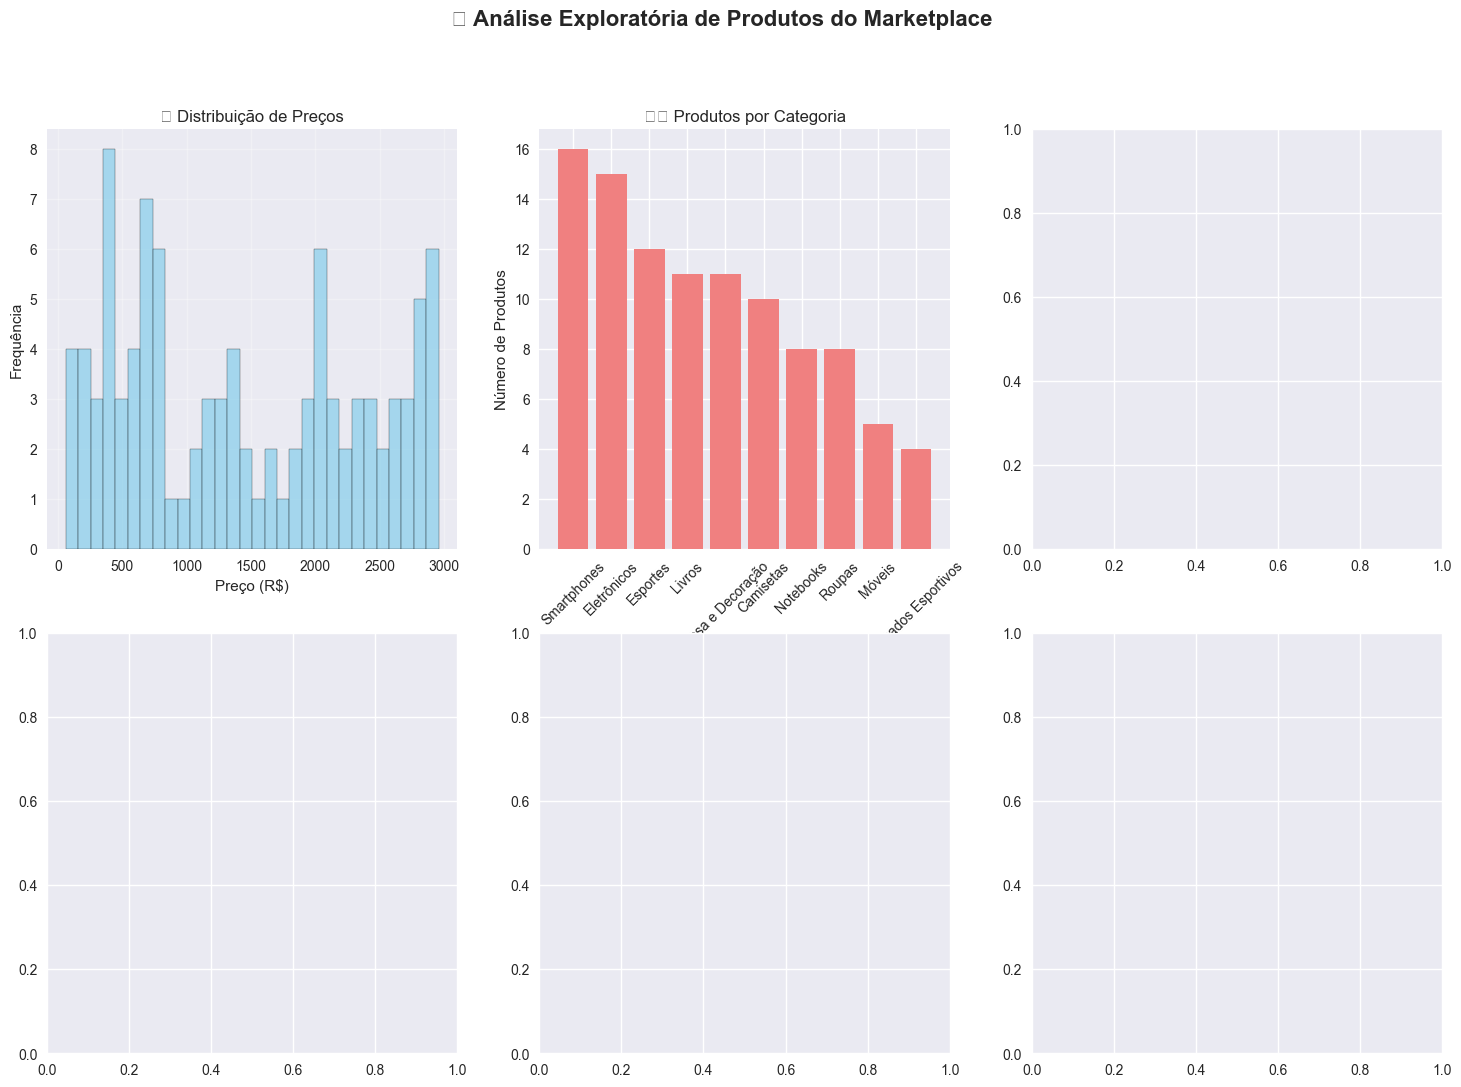

In [4]:
# Configurar o tamanho das figuras
plt.rcParams['figure.figsize'] = (15, 10)

# Criar subplots para várias visualizações
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📊 Análise Exploratória de Produtos do Marketplace', fontsize=16, fontweight='bold')

# 1. Distribuição de Preços
axes[0, 0].hist(df_products['price'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('💰 Distribuição de Preços')
axes[0, 0].set_xlabel('Preço (R$)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].grid(True, alpha=0.3)

# 2. Produtos por Categoria
category_counts = df_products['category_name'].value_counts()
axes[0, 1].bar(category_counts.index, category_counts.values, color='lightcoral')
axes[0, 1].set_title('🏷️ Produtos por Categoria')
axes[0, 1].set_xlabel('Categoria')
axes[0, 1].set_ylabel('Número de Produtos')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Distribuição de Estoque
axes[0, 2].hist(df_products['stock_quantity'], bins=25, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('📦 Distribuição de Estoque')
axes[0, 2].set_xlabel('Quantidade em Estoque')
axes[0, 2].set_ylabel('Frequência')
axes[0, 2].grid(True, alpha=0.3)

# 4. Produtos por Marca
brand_counts = df_products['brand_name'].value_counts()
axes[1, 0].bar(brand_counts.index, brand_counts.values, color='gold')
axes[1, 0].set_title('🏢 Produtos por Marca')
axes[1, 0].set_xlabel('Marca')
axes[1, 0].set_ylabel('Número de Produtos')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Reputação dos Vendedores
axes[1, 1].hist(df_products['seller_reputation'], bins=20, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('⭐ Distribuição de Reputação dos Vendedores')
axes[1, 1].set_xlabel('Reputação (1-5)')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].grid(True, alpha=0.3)

# 6. Status dos Produtos
active_counts = df_products['active'].value_counts()
axes[1, 2].pie(active_counts.values, labels=['Ativo', 'Inativo'], autopct='%1.1f%%', 
               colors=['lightgreen', 'lightcoral'], startangle=90)
axes[1, 2].set_title('🔄 Status dos Produtos')

plt.tight_layout()
plt.show()

# Estatísticas resumidas
print("\n📈 ESTATÍSTICAS PRINCIPAIS:")
print(f"💰 Preço médio: R$ {df_products['price'].mean():.2f}")
print(f"💰 Preço mediano: R$ {df_products['price'].median():.2f}")
print(f"📦 Estoque médio: {df_products['stock_quantity'].mean():.0f} unidades")
print(f"⭐ Reputação média: {df_products['seller_reputation'].mean():.2f}")
print(f"🏷️ Categorias únicas: {df_products['category_name'].nunique()}")
print(f"🏢 Marcas únicas: {df_products['brand_name'].nunique()}")
print(f"👤 Vendedores únicos: {df_products['seller_name'].nunique()}")

## 5. Analytics Avançados

Análises mais sofisticadas para descobrir padrões e correlações nos dados.

In [ ]:
# 1. Matriz de Correlação
plt.figure(figsize=(12, 8))
numeric_columns = ['price', 'stock_quantity', 'seller_reputation']
correlation_matrix = df_products[numeric_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('🔗 Matriz de Correlação entre Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Boxplot de Preços por Categoria
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_products, x='category_name', y='price')
plt.title('📊 Distribuição de Preços por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Preço (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Relação entre Reputação do Vendedor e Preço
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(df_products['seller_reputation'], df_products['price'], alpha=0.6, color='blue')
plt.xlabel('Reputação do Vendedor')
plt.ylabel('Preço (R$)')
plt.title('💎 Reputação vs Preço')
plt.grid(True, alpha=0.3)

# 4. Preço médio por marca
plt.subplot(1, 2, 2)
brand_avg_price = df_products.groupby('brand_name')['price'].mean().sort_values(ascending=False)
plt.bar(brand_avg_price.index, brand_avg_price.values, color='orange', alpha=0.7)
plt.xlabel('Marca')
plt.ylabel('Preço Médio (R$)')
plt.title('🏢 Preço Médio por Marca')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Análise temporal (se dados de data estiverem disponíveis)
if 'created_at' in df_products.columns and df_products['created_at'].notna().any():
    plt.figure(figsize=(15, 6))
    
    # Produtos criados por mês
    df_products['month_year'] = df_products['created_at'].dt.to_period('M')
    monthly_products = df_products.groupby('month_year').size()
    
    plt.subplot(1, 2, 1)
    monthly_products.plot(kind='line', marker='o', color='green')
    plt.title('📈 Produtos Criados por Mês')
    plt.xlabel('Mês/Ano')
    plt.ylabel('Número de Produtos')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Preço médio por mês
    monthly_avg_price = df_products.groupby('month_year')['price'].mean()
    plt.subplot(1, 2, 2)
    monthly_avg_price.plot(kind='line', marker='s', color='red')
    plt.title('💰 Preço Médio por Mês')
    plt.xlabel('Mês/Ano')
    plt.ylabel('Preço Médio (R$)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 6. Top 10 produtos mais caros
print("\n💎 TOP 10 PRODUTOS MAIS CAROS:")
top_expensive = df_products.nlargest(10, 'price')[['name', 'price', 'category_name', 'brand_name']]
display(top_expensive)

# 7. Análise por vendedor
print("\n👤 ANÁLISE POR VENDEDOR:")
seller_analysis = df_products.groupby('seller_name').agg({
    'price': ['mean', 'count'],
    'seller_reputation': 'first',
    'stock_quantity': 'sum'
}).round(2)

seller_analysis.columns = ['Preço Médio', 'Qtd Produtos', 'Reputação', 'Estoque Total']
seller_analysis = seller_analysis.sort_values('Qtd Produtos', ascending=False)
display(seller_analysis)

## 6. Filtros Interativos e Análises Personalizadas

Ferramentas para exploração dinâmica dos dados com filtros personalizáveis.

In [ ]:
def filter_products(df, 
                   min_price=None, max_price=None,
                   categories=None, brands=None, sellers=None,
                   min_stock=None, min_reputation=None,
                   active_only=True):
    """
    Filtra produtos baseado em critérios especificados
    
    Parâmetros:
    - min_price, max_price: filtros de preço
    - categories, brands, sellers: listas de valores para filtrar
    - min_stock: estoque mínimo
    - min_reputation: reputação mínima do vendedor
    - active_only: mostrar apenas produtos ativos
    """
    filtered_df = df.copy()
    
    if active_only:
        filtered_df = filtered_df[filtered_df['active'] == True]
    
    if min_price is not None:
        filtered_df = filtered_df[filtered_df['price'] >= min_price]
    
    if max_price is not None:
        filtered_df = filtered_df[filtered_df['price'] <= max_price]
    
    if categories:
        filtered_df = filtered_df[filtered_df['category_name'].isin(categories)]
    
    if brands:
        filtered_df = filtered_df[filtered_df['brand_name'].isin(brands)]
    
    if sellers:
        filtered_df = filtered_df[filtered_df['seller_name'].isin(sellers)]
    
    if min_stock is not None:
        filtered_df = filtered_df[filtered_df['stock_quantity'] >= min_stock]
    
    if min_reputation is not None:
        filtered_df = filtered_df[filtered_df['seller_reputation'] >= min_reputation]
    
    return filtered_df

def analyze_filtered_data(filtered_df, title="Análise dos Dados Filtrados"):
    """
    Realiza análise rápida dos dados filtrados
    """
    print(f"\n🔍 {title.upper()}")
    print("=" * 60)
    print(f"📊 Total de produtos: {len(filtered_df)}")
    
    if len(filtered_df) == 0:
        print("❌ Nenhum produto encontrado com os filtros aplicados.")
        return
    
    print(f"💰 Preço médio: R$ {filtered_df['price'].mean():.2f}")
    print(f"💰 Faixa de preço: R$ {filtered_df['price'].min():.2f} - R$ {filtered_df['price'].max():.2f}")
    print(f"📦 Estoque total: {filtered_df['stock_quantity'].sum():.0f} unidades")
    print(f"⭐ Reputação média: {filtered_df['seller_reputation'].mean():.2f}")
    
    print(f"\n🏷️ Top 3 categorias:")
    top_categories = filtered_df['category_name'].value_counts().head(3)
    for category, count in top_categories.items():
        print(f"   • {category}: {count} produtos")
    
    print(f"\n🏢 Top 3 marcas:")
    top_brands = filtered_df['brand_name'].value_counts().head(3)
    for brand, count in top_brands.items():
        print(f"   • {brand}: {count} produtos")
    
    return filtered_df

# Exemplos de uso dos filtros
print("🔍 EXEMPLOS DE FILTROS PERSONALIZADOS")
print("=" * 50)

# Exemplo 1: Produtos de luxo (preço > R$ 500)
luxury_products = filter_products(df_products, min_price=500)
analyze_filtered_data(luxury_products, "Produtos de Luxo (> R$ 500)")

# Exemplo 2: Produtos em estoque com boa reputação
quality_products = filter_products(df_products, min_stock=10, min_reputation=4.0)
analyze_filtered_data(quality_products, "Produtos com Estoque e Boa Reputação")

# Exemplo 3: Produtos específicos por categoria
if 'category_name' in df_products.columns:
    available_categories = df_products['category_name'].unique()
    if len(available_categories) > 0:
        sample_category = [available_categories[0]]
        category_products = filter_products(df_products, categories=sample_category)
        analyze_filtered_data(category_products, f"Produtos da Categoria: {sample_category[0]}")

print("\n" + "="*60)
print("💡 DICAS DE USO:")
print("• Modifique os parâmetros da função filter_products() para criar seus próprios filtros")
print("• Use analyze_filtered_data() para obter insights rápidos dos dados filtrados")
print("• Combine múltiplos filtros para análises mais específicas")
print("• Execute as células acima novamente após modificar os filtros")

## 7. Gráficos Interativos com Plotly

Visualizações interativas para exploração mais dinâmica dos dados.

In [ ]:
# 1. Gráfico de dispersão interativo: Preço vs Estoque
fig1 = px.scatter(df_products, 
                  x='stock_quantity', 
                  y='price',
                  color='category_name',
                  size='seller_reputation',
                  hover_data=['name', 'brand_name', 'seller_name'],
                  title='📊 Preço vs Estoque (Tamanho = Reputação do Vendedor)',
                  labels={'stock_quantity': 'Quantidade em Estoque',
                          'price': 'Preço (R$)',
                          'category_name': 'Categoria'})

fig1.update_layout(height=600)
fig1.show()

# 2. Gráfico de barras interativo: Produtos por categoria
category_counts = df_products['category_name'].value_counts()
fig2 = px.bar(x=category_counts.index, 
              y=category_counts.values,
              title='🏷️ Distribuição de Produtos por Categoria',
              labels={'x': 'Categoria', 'y': 'Número de Produtos'},
              color=category_counts.values,
              color_continuous_scale='viridis')

fig2.update_layout(height=500)
fig2.show()

# 3. Boxplot interativo: Preços por marca
fig3 = px.box(df_products, 
              x='brand_name', 
              y='price',
              title='📦 Distribuição de Preços por Marca',
              labels={'brand_name': 'Marca', 'price': 'Preço (R$)'})

fig3.update_layout(height=500)
fig3.update_xaxes(tickangle=45)
fig3.show()

# 4. Histograma interativo: Distribuição de reputação
fig4 = px.histogram(df_products, 
                    x='seller_reputation',
                    nbins=20,
                    title='⭐ Distribuição de Reputação dos Vendedores',
                    labels={'seller_reputation': 'Reputação do Vendedor',
                            'count': 'Frequência'})

fig4.update_layout(height=400)
fig4.show()

# 5. Mapa de calor de vendedores vs categorias
if len(df_products) > 0:
    seller_category_matrix = pd.crosstab(df_products['seller_name'], df_products['category_name'])
    
    fig5 = px.imshow(seller_category_matrix.values,
                     x=seller_category_matrix.columns,
                     y=seller_category_matrix.index,
                     color_continuous_scale='Blues',
                     title='🔥 Mapa de Calor: Vendedores vs Categorias',
                     labels={'x': 'Categoria', 'y': 'Vendedor', 'color': 'Número de Produtos'})
    
    fig5.update_layout(height=600)
    fig5.show()

print("✨ Gráficos interativos criados com sucesso!")
print("💡 Dica: Passe o mouse sobre os pontos para ver mais informações")
print("🔍 Use as ferramentas de zoom e seleção para explorar os dados")

## 8. Exportar Dados e Conclusões

Ferramentas para exportar dados filtrados e gerar relatórios.

In [ ]:
def export_analysis_report(df, filename='product_analysis_report'):
    """
    Exporta um relatório completo da análise em diferentes formatos
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 1. Exportar dados em CSV
    csv_filename = f"{filename}_{timestamp}.csv"
    df.to_csv(csv_filename, index=False, encoding='utf-8')
    print(f"📄 Dados exportados para: {csv_filename}")
    
    # 2. Criar relatório estatístico
    report_filename = f"{filename}_summary_{timestamp}.txt"
    with open(report_filename, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("RELATÓRIO DE ANÁLISE DE PRODUTOS - MARKETPLACE\n")
        f.write("=" * 60 + "\n\n")
        
        f.write(f"Data/Hora da Análise: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n")
        f.write(f"Total de Produtos Analisados: {len(df)}\n\n")
        
        f.write("ESTATÍSTICAS PRINCIPAIS:\n")
        f.write("-" * 30 + "\n")
        if 'price' in df.columns:
            f.write(f"Preço Médio: R$ {df['price'].mean():.2f}\n")
            f.write(f"Preço Mediano: R$ {df['price'].median():.2f}\n")
            f.write(f"Faixa de Preços: R$ {df['price'].min():.2f} - R$ {df['price'].max():.2f}\n")
        
        if 'stock_quantity' in df.columns:
            f.write(f"Estoque Total: {df['stock_quantity'].sum():.0f} unidades\n")
            f.write(f"Estoque Médio por Produto: {df['stock_quantity'].mean():.1f} unidades\n")
        
        if 'seller_reputation' in df.columns:
            f.write(f"Reputação Média dos Vendedores: {df['seller_reputation'].mean():.2f}\n")
        
        f.write(f"\nCategorias Únicas: {df['category_name'].nunique()}\n")
        f.write(f"Marcas Únicas: {df['brand_name'].nunique()}\n")
        f.write(f"Vendedores Únicos: {df['seller_name'].nunique()}\n\n")
        
        f.write("TOP 5 CATEGORIAS:\n")
        f.write("-" * 20 + "\n")
        top_categories = df['category_name'].value_counts().head(5)
        for i, (category, count) in enumerate(top_categories.items(), 1):
            f.write(f"{i}. {category}: {count} produtos\n")
        
        f.write("\nTOP 5 MARCAS:\n")
        f.write("-" * 15 + "\n")
        top_brands = df['brand_name'].value_counts().head(5)
        for i, (brand, count) in enumerate(top_brands.items(), 1):
            f.write(f"{i}. {brand}: {count} produtos\n")
    
    print(f"📊 Relatório estatístico salvo em: {report_filename}")
    
    # 3. Exportar dados em Excel (se xlsxwriter estiver disponível)
    try:
        excel_filename = f"{filename}_{timestamp}.xlsx"
        with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
            # Dados completos
            df.to_excel(writer, sheet_name='Dados_Completos', index=False)
            
            # Resumo por categoria
            category_summary = df.groupby('category_name').agg({
                'price': ['mean', 'count', 'min', 'max'],
                'stock_quantity': 'sum',
                'seller_reputation': 'mean'
            }).round(2)
            category_summary.to_excel(writer, sheet_name='Resumo_Categorias')
            
            # Resumo por marca
            brand_summary = df.groupby('brand_name').agg({
                'price': ['mean', 'count'],
                'stock_quantity': 'sum'
            }).round(2)
            brand_summary.to_excel(writer, sheet_name='Resumo_Marcas')
        
        print(f"📈 Planilha Excel criada: {excel_filename}")
    except ImportError:
        print("⚠️  xlsxwriter não está instalado. Instale com: pip install xlsxwriter")
    
    return csv_filename, report_filename

# Função para criar filtros personalizados e exportar
def create_custom_filter():
    """
    Interface simples para criar filtros personalizados
    """
    print("\n🔧 CRIADOR DE FILTROS PERSONALIZADOS")
    print("=" * 40)
    print("Modifique os valores abaixo para criar seu filtro:")
    print("\n# Exemplo de uso:")
    print("filtered_data = filter_products(")
    print("    df_products,")
    print("    min_price=50,           # Preço mínimo")
    print("    max_price=500,          # Preço máximo") 
    print("    categories=['Eletrônicos', 'Roupas'],  # Categorias específicas")
    print("    min_stock=5,            # Estoque mínimo")
    print("    min_reputation=3.0      # Reputação mínima")
    print(")")
    print("\n# Para exportar os dados filtrados:")
    print("export_analysis_report(filtered_data, 'meu_filtro_personalizado')")
    
    print(f"\n📋 VALORES DISPONÍVEIS NO DATASET:")
    print(f"Categorias: {list(df_products['category_name'].unique())}")
    print(f"Marcas: {list(df_products['brand_name'].unique())}")
    print(f"Vendedores: {list(df_products['seller_name'].unique())}")
    print(f"Faixa de preços: R$ {df_products['price'].min():.2f} - R$ {df_products['price'].max():.2f}")

# Executar exemplos
print("💾 EXPORTANDO ANÁLISE COMPLETA DOS DADOS...")
export_analysis_report(df_products, 'marketplace_analysis_complete')

print("\n" + "="*60)
create_custom_filter()

print("\n" + "="*60)
print("🎉 NOTEBOOK DE ANÁLISE CONCLUÍDO!")
print("✅ Você agora tem ferramentas completas para:")
print("   • Carregar dados do Elasticsearch")
print("   • Explorar e visualizar informações de produtos")
print("   • Criar filtros personalizados") 
print("   • Gerar gráficos interativos")
print("   • Exportar relatórios e dados")
print("\n💡 Dicas finais:")
print("   • Execute as células em ordem para melhor experiência")
print("   • Modifique os filtros para suas necessidades específicas")
print("   • Use os gráficos interativos para explorar padrões")
print("   • Exporte os dados filtrados para análises externas")